In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('Kyrgyzstan.csv',sep=';',header=None, encoding='latin1')
print("Raw data head")
print(df.head(10))
df.info()

Raw data head
                                 0                                  1   \
0  Ìàìëåêåòòèê áþäæåòòèí ÷ûãàøàëàðû  Ðàñõîäû ãîñóäàðñòâåííîãî áþäæåòà    
1                               NaN                                NaN   
2                        (ìëí. ñîì)                       (ìëí. ñîìîâ)   
3                               NaN                                NaN   
4           Ê?ðñ?òê?÷ò?ðä?í àòàëûøû           Íàèìåíîâàíèå ïîêàçàòåëåé   
5             Êûðãûç Ðåñïóáëèêàñû1)            Êûðãûçñêàÿ Ðåñïóáëèêà1)   
6                     Áàòêåí îáëóñó                 Áàòêåíñêàÿ îáëàñòü   
7                 Æàëàë-Àáàä îáëóñó            Äæàëàë-Àáàäñêàÿ îáëàñòü   
8                   Ûñûê-Ê?ë îáëóñó             Èññûê-Êóëüñêàÿ îáëàñòü   
9                      Íàðûí îáëóñó                  Íàðûíñêàÿ îáëàñòü   

                              2         3         4         5         6   \
0  The state budget expenditures       NaN       NaN       NaN       NaN   
1                  

In [ ]:
# Reload with correct header and skipping metadata
df = pd.read_csv('Kyrgyzstan.csv', sep=';', skiprows=4, encoding='latin1')

# Display the first few rows and check columns
print("Data head after skipping 4 rows:")
print(df.head())

# Check the tail to see if there are any footnotes or empty rows at the bottom
print("\nData tail:")
print(df.tail())

# Check column names
print("\nColumn names:")
print(df.columns)

Data head after skipping 4 rows:
  Ê?ðñ?òê?÷ò?ðä?í àòàëûøû Íàèìåíîâàíèå ïîêàçàòåëåé              Items  \
0   Êûðãûç Ðåñïóáëèêàñû1)  Êûðãûçñêàÿ Ðåñïóáëèêà1)  Kyrgyz Republic1)   
1           Áàòêåí îáëóñó       Áàòêåíñêàÿ îáëàñòü      Batken oblast   
2       Æàëàë-Àáàä îáëóñó  Äæàëàë-Àáàäñêàÿ îáëàñòü  Jalal-Abat oblast   
3         Ûñûê-Ê?ë îáëóñó   Èññûê-Êóëüñêàÿ îáëàñòü   Yssyk-Kul oblast   
4            Íàðûí îáëóñó        Íàðûíñêàÿ îáëàñòü       Naryn oblast   

       2006      2007      2008      2009      2010      2011       2012  ...  \
0  25 296,6  35 859,4  45 032,0  58 628,2  68 781,2  91 544,1  107 240,4  ...   
1     418,5     543,1     703,1     854,9     936,2   1 459,1    1 795,1  ...   
2     932,2   1 254,4   1 631,5   1 992,1   2 292,3   3 324,9    3 796,4  ...   
3     613,5     679,1     929,4   1 127,0   1 040,9   1 522,6    1 691,7  ...   
4     389,1     450,8     665,5     776,1     831,8   1 434,8    1 605,4  ...   

        2016       2017       2018       

In [ ]:
# 1. Remove footnotes and empty rows
# We can keep only rows where the 'Items' column is not null and doesn't look like a footnote
df_clean = df.dropna(subset=['Items']).copy()
# Remove rows that start with "1)" or "*" in Items
df_clean = df_clean[~df_clean['Items'].str.startswith(('1)', '*'), na=False)]

# 2. Clean the numeric columns
year_cols = [str(year) for year in range(2006, 2026)]

def clean_numeric(x):
    if pd.isna(x):
        return x
    if isinstance(x, str):
        # Remove spaces and replace comma with dot
        x = x.replace(' ', '').replace(',', '.')
    try:
        return float(x)
    except:
        return x

for col in year_cols:
    df_clean[col] = df_clean[col].apply(clean_numeric)

# 3. Clean the region names in 'Items'
df_clean['Items'] = df_clean['Items'].str.replace('1)', '', regex=False).str.strip()

# 4. Selection: Items and years
df_final = df_clean[['Items'] + year_cols]

print("Cleaned data head:")
print(df_final.head())
print("\nData types:")
print(df_final.dtypes)

# Save to CSV
df_final.to_csv('Kyrgyzstan_budget_cleaned.csv', index=False)

Cleaned data head:
               Items     2006     2007     2008     2009     2010     2011  \
0    Kyrgyz Republic  25296.6  35859.4  45032.0  58628.2  68781.2  91544.1   
1      Batken oblast    418.5    543.1    703.1    854.9    936.2   1459.1   
2  Jalal-Abat oblast    932.2   1254.4   1631.5   1992.1   2292.3   3324.9   
3   Yssyk-Kul oblast    613.5    679.1    929.4   1127.0   1040.9   1522.6   
4       Naryn oblast    389.1    450.8    665.5    776.1    831.8   1434.8   

       2012      2013      2014  ...      2016      2017      2018      2019  \
0  107240.4  104271.3  121303.7  ...  151558.9  166023.6  157796.0  167843.9   
1    1795.1    1472.4     826.2  ...     851.5     903.7    1031.0    1079.5   
2    3796.4    2939.8    1682.1  ...    2014.8    2015.2    2359.0    2538.1   
3    1691.7    1487.8    1044.7  ...    1120.9    1185.1    1257.4    1373.4   
4    1605.4    1209.0     649.8  ...     711.7     780.1     884.5     883.7   

       2020      2021      2022

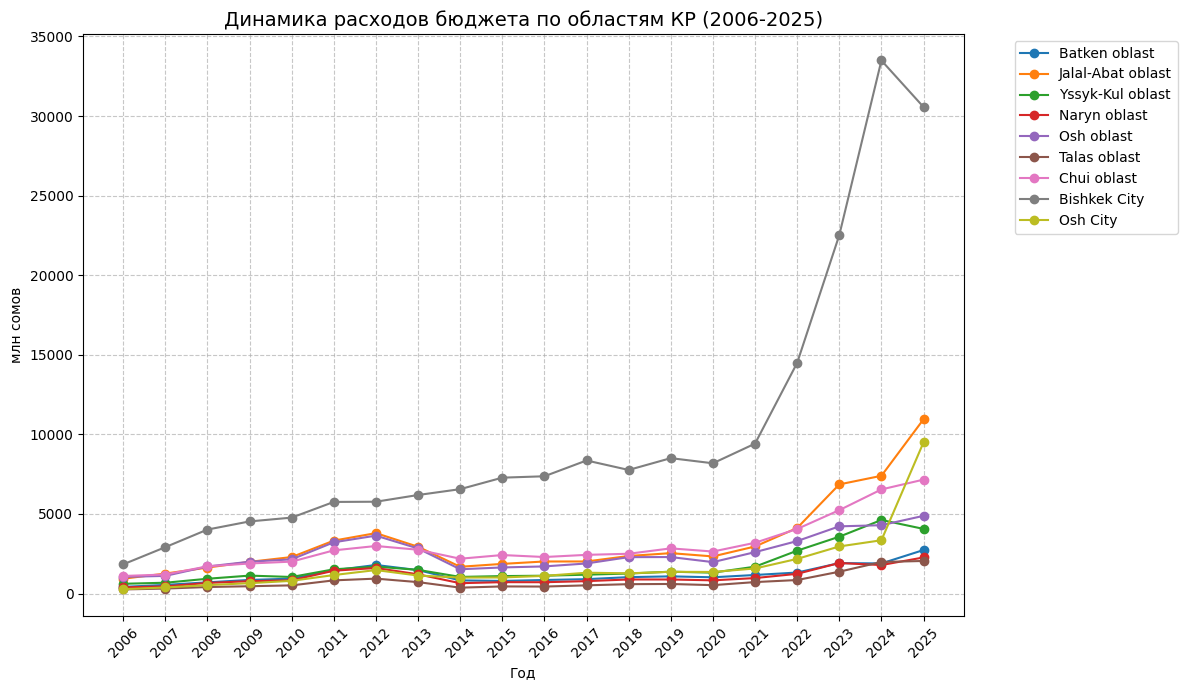

Очищенные данные:
               Items     2006     2007     2008     2009     2010     2011  \
0    Kyrgyz Republic  25296.6  35859.4  45032.0  58628.2  68781.2  91544.1   
1      Batken oblast    418.5    543.1    703.1    854.9    936.2   1459.1   
2  Jalal-Abat oblast    932.2   1254.4   1631.5   1992.1   2292.3   3324.9   
3   Yssyk-Kul oblast    613.5    679.1    929.4   1127.0   1040.9   1522.6   
4       Naryn oblast    389.1    450.8    665.5    776.1    831.8   1434.8   

       2012      2013      2014  ...      2016      2017      2018      2019  \
0  107240.4  104271.3  121303.7  ...  151558.9  166023.6  157796.0  167843.9   
1    1795.1    1472.4     826.2  ...     851.5     903.7    1031.0    1079.5   
2    3796.4    2939.8    1682.1  ...    2014.8    2015.2    2359.0    2538.1   
3    1691.7    1487.8    1044.7  ...    1120.9    1185.1    1257.4    1373.4   
4    1605.4    1209.0     649.8  ...     711.7     780.1     884.5     883.7   

       2020      2021      2022 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Загрузка и первичная подготовка
# Читаем файл, пропуская первые 4 строки заголовков
df = pd.read_csv('Kyrgyzstan.csv', sep=';', skiprows=4, encoding='latin1')

# 2. Очистка данных (ваша логика)
# Удаляем пустые строки в колонке Items
df_clean = df.dropna(subset=['Items']).copy()

# Удаляем строки со сносками или лишними символами
df_clean = df_clean[~df_clean['Items'].str.startswith(('1)', '*'), na=False)]

# Список колонок с годами
year_cols = [str(year) for year in range(2006, 2026)]

def clean_numeric(x):
    if pd.isna(x):
        return 0.0
    if isinstance(x, str):
        # Удаляем пробелы (включая неразрывные) и меняем запятую на точку
        x = x.replace(' ', '').replace('\xa0', '').replace(',', '.')
    try:
        return float(x)
    except:
        return 0.0

# Применяем очистку к числовым колонкам
for col in year_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(clean_numeric)

# Очищаем названия регионов от сносок "1)"
df_clean['Items'] = df_clean['Items'].str.replace('1)', '', regex=False).str.strip()

# 3. Финальный выбор данных
df_final = df_clean[['Items'] + year_cols]

# Сохраняем результат
df_final.to_csv('Kyrgyzstan_budget_cleaned.csv', index=False)

# 4. Визуализация: Как показать все области
# Убираем "Kyrgyz Republic", чтобы видеть только области (иначе общая сумма подавит график)
df_oblasts = df_final[df_final['Items'] != 'Kyrgyz Republic']

plt.figure(figsize=(12, 7))
for index, row in df_oblasts.iterrows():
    plt.plot(year_cols, row[year_cols], marker='o', label=row['Items'])

plt.title('Динамика расходов бюджета по областям КР (2006-2025)', fontsize=14)
plt.xlabel('Год')
plt.ylabel('млн сомов')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Показываем график
plt.show()

print("Очищенные данные:")
print(df_final.head())

In [ ]:
# 1. Выбираем нужные столбцы, включая процентили
# Метод .describe() уже рассчитал их, нам нужно просто их отобразить
final_report = summary_table[[
    'Среднее',
    'Мин.',
    '25%',
    '50% (Медиана)',
    '75%',
    'Макс.',
    'Общая сумма',
    'Во сколько раз вырос'
]].sort_values(by='Общая сумма', ascending=False)

# 2. Применяем стилизацию (как на скриншоте)
styled_report = final_report.style \
    .format({
        'Среднее': '{:,.1f}',
        'Мин.': '{:,.1f}',
        '25%': '{:,.1f}',
        '50% (Медиана)': '{:,.1f}',
        '75%': '{:,.1f}',
        'Макс.': '{:,.1f}',
        'Общая сумма': '{:,.1f}',
        'Во сколько раз вырос': '{:,.2f}x'
    }) \
    .set_caption("Детальный статистический анализ бюджета по регионам (2006-2025)") \
    .background_gradient(cmap='Blues', subset=['Общая сумма']) # Подсветка самых крупных сумм

# Вывод
styled_report

,Среднее,Мин.,25%,50% (Медиана),75%,Макс.,Общая сумма,Во сколько раз вырос
Items,,,,,,,,
Kyrgyz Republic,"177,996.9","25,296.6","85,853.4","143,065.5","181,830.6","622,978.1","3,559,937.5",24.63x
Bishkek City,"10,014.7","1,833.1","5,509.5","7,324.2","8,734.6","33,491.0","200,293.1",16.67x
Jalal-Abat oblast,"3,262.4",932.2,"1,959.9","2,345.6","3,442.8","10,949.5","65,248.0",11.75x
Chui oblast,"2,992.7","1,103.8","2,142.2","2,569.5","3,038.2","7,157.7","59,853.2",6.48x
Osh oblast,"2,515.2","1,046.7","1,703.1","2,218.4","3,239.8","4,881.8","50,304.8",4.66x
Osh City,"1,719.3",274.6,952.5,"1,216.2","1,500.4","9,499.8","34,386.9",34.60x
Yssyk-Kul oblast,"1,705.9",613.5,"1,083.9","1,284.5","1,689.2","4,621.3","34,117.8",6.62x
Batken oblast,"1,185.6",418.5,845.2,"1,026.0","1,462.4","2,733.8","23,712.9",6.53x
Naryn oblast,"1,050.2",389.1,714.9,857.8,"1,287.9","2,268.0","21,004.7",5.83x


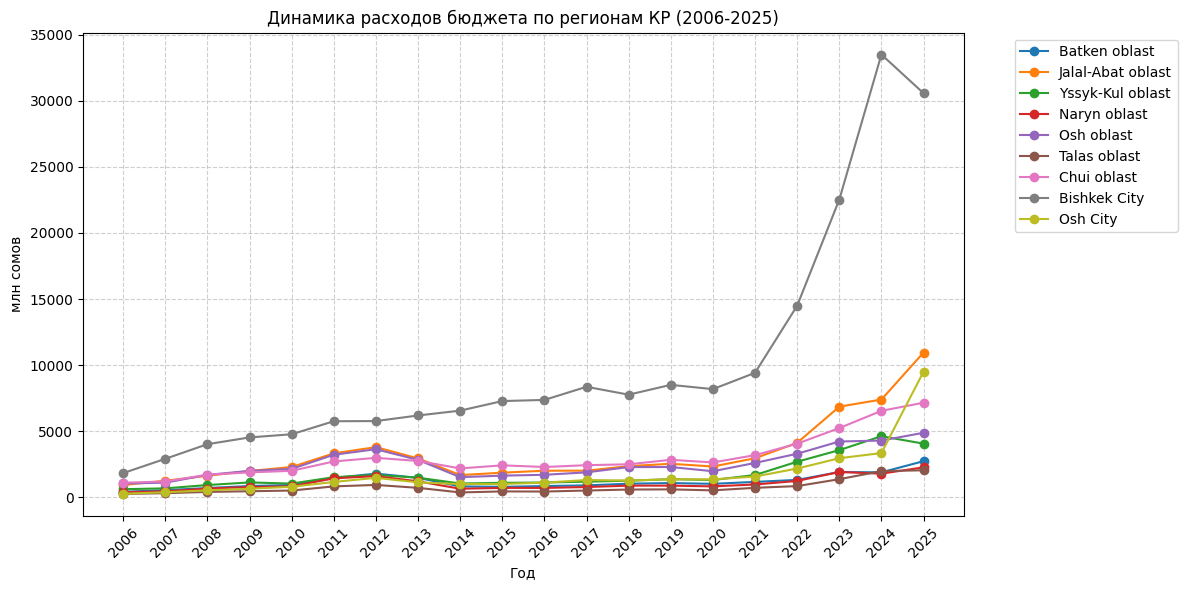

In [ ]:
# Загрузка очищенных данных
df = pd.read_csv('Kyrgyzstan_budget_cleaned.csv')
year_cols = [str(y) for y in range(2006, 2026)]

# Исключаем общие данные по стране для корректного масштаба областей
df_regions = df[df['Items'] != 'Kyrgyz Republic']

# Настройка размера графика
plt.figure(figsize=(12, 6))

# Построение линий для каждого региона
for index, row in df_regions.iterrows():
    plt.plot(year_cols, row[year_cols], marker='o', label=row['Items'])

# Оформление
plt.title('Динамика расходов бюджета по регионам КР (2006-2025)')
plt.xlabel('Год')
plt.ylabel('млн сомов')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

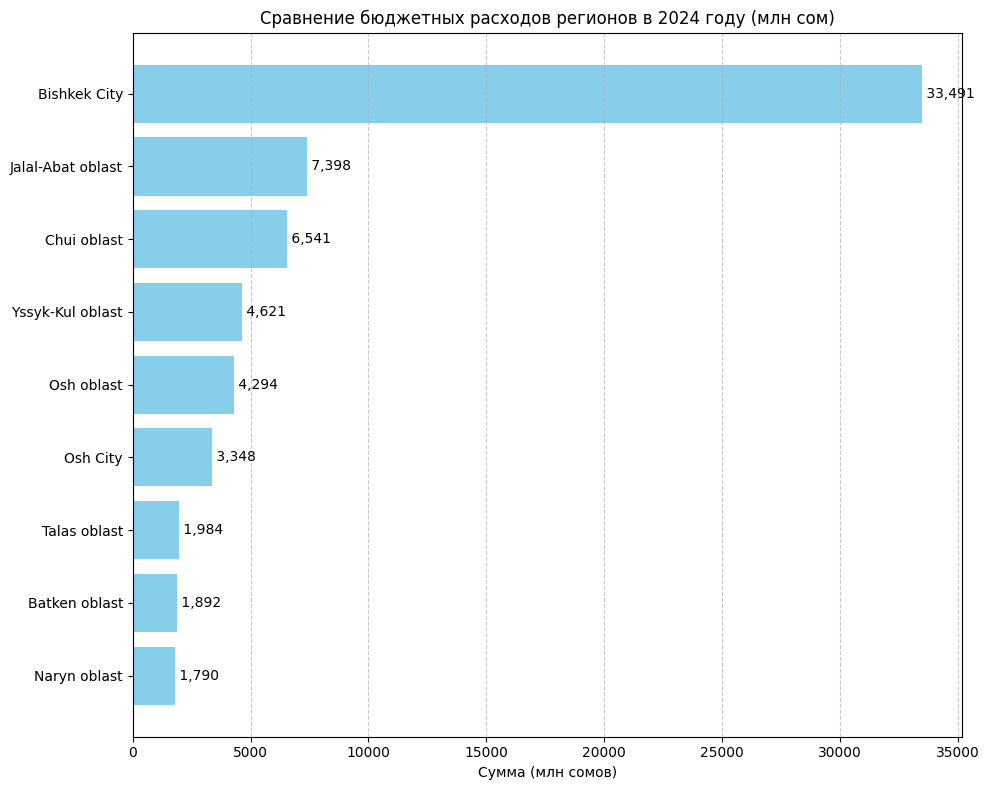

In [ ]:
# Выбираем год для сравнения
target_year = '2024'

# Сортировка данных по возрастанию для красивого отображения на графике
df_sorted = df_regions.sort_values(by=target_year, ascending=True)

plt.figure(figsize=(10, 8))
bars = plt.barh(df_sorted['Items'], df_sorted[target_year], color='skyblue')

# Добавление подписей значений в конце каждого столбца
for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f' {bar.get_width():,.0f}', va='center')

plt.title(f'Сравнение бюджетных расходов регионов в {target_year} году (млн сом)')
plt.xlabel('Сумма (млн сомов)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

Regression Summary:
R-squared: 0.7557
Annual Average Growth (Slope): 22137.63 mln soms per year


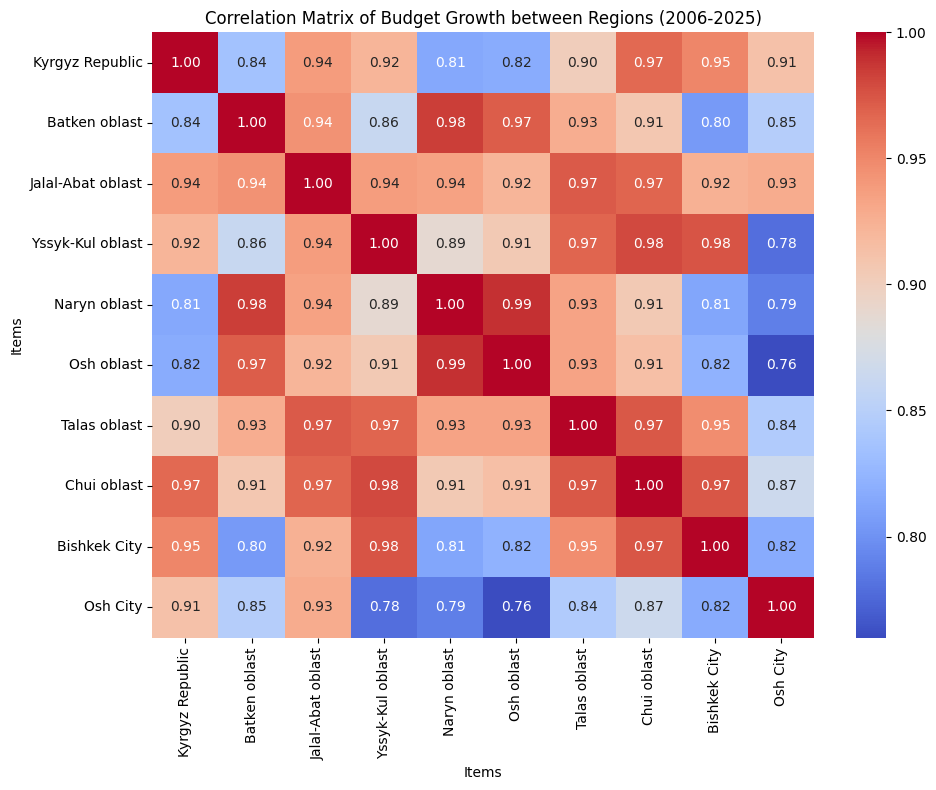

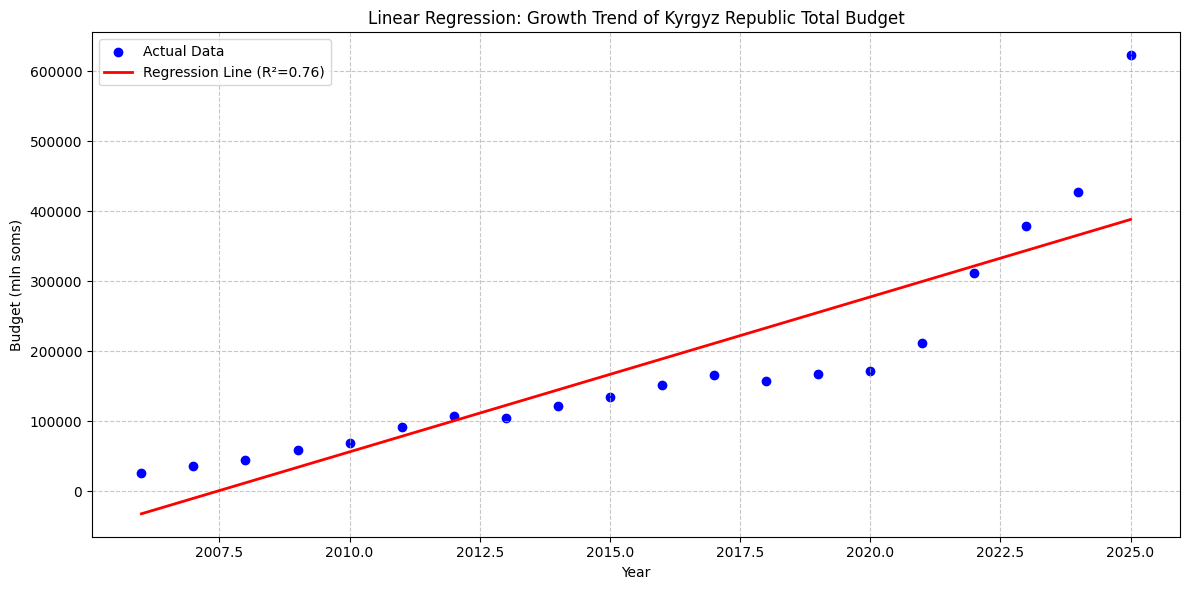

In [ ]:

import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns

# Load cleaned data
df = pd.read_csv('Kyrgyzstan_budget_cleaned.csv')
year_cols = [str(y) for y in range(2006, 2026)]
years = np.array([int(y) for y in year_cols]).reshape(-1, 1)

# --- 1. Correlation Analysis (between regions) ---
# We transpose to have years as rows and regions as columns
df_corr = df.set_index('Items')[year_cols].T.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Budget Growth between Regions (2006-2025)')
plt.tight_layout()
plt.savefig('correlation_matrix.png')

# --- 2. Regression Analysis (National Budget Trend) ---
# Target: Kyrgyz Republic total budget
y = df[df['Items'] == 'Kyrgyz Republic'][year_cols].values.flatten()

# Fit Linear Regression
model = LinearRegression()
model.fit(years, y)
y_pred = model.predict(years)

# Metrics
r2 = model.score(years, y)
slope = model.coef_[0]

plt.figure(figsize=(12, 6))
plt.scatter(years, y, color='blue', label='Actual Data')
plt.plot(years, y_pred, color='red', linewidth=2, label=f'Regression Line (R²={r2:.2f})')
plt.title('Linear Regression: Growth Trend of Kyrgyz Republic Total Budget')
plt.xlabel('Year')
plt.ylabel('Budget (mln soms)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('regression_analysis.png')

print(f"Regression Summary:")
print(f"R-squared: {r2:.4f}")
print(f"Annual Average Growth (Slope): {slope:.2f} mln soms per year")

In [ ]:
import pandas as pd
from scipy import stats

# 1. Подготовка данных
df = pd.read_csv('Kyrgyzstan_budget_cleaned.csv')
# Разделяем годы на два десятилетия
past_years = [str(y) for y in range(2006, 2016)]
modern_years = [str(y) for y in range(2016, 2026)]

# Берем данные по всей республике для теста
past_data = df[df['Items'] == 'Kyrgyz Republic'][past_years].values.flatten()
modern_data = df[df['Items'] == 'Kyrgyz Republic'][modern_years].values.flatten()

# 2. Проведение Т-теста (Независимый t-критерий Стьюдента)
# Гипотеза H0: Средние расходы в оба периода одинаковы.
# Гипотеза H1: Средние расходы в современный период значимо выше.
t_stat, p_value = stats.ttest_ind(modern_data, past_data, equal_var=False)

# 3. Категориальный анализ (Сравнение долей)
# Посмотрим на долю Бишкека в общем бюджете в 2006 vs 2025
bishkek_2006 = df[df['Items'] == 'Bishkek City']['2006'].values[0]
total_2006 = df[df['Items'] == 'Kyrgyz Republic']['2006'].values[0]

bishkek_2025 = df[df['Items'] == 'Bishkek City']['2025'].values[0]
total_2025 = df[df['Items'] == 'Kyrgyz Republic']['2025'].values[0]

print("--- РЕЗУЛЬТАТЫ ПРОВЕРКИ ГИПОТЕЗ ---")
print(f"T-статистика: {t_stat:.2f}")
print(f"P-значение: {p_value:.10f}")

if p_value < 0.05:
    print("Результат: Статистически значим. Мы отвергаем нулевую гипотезу.")
    print("Вывод: Бюджетные расходы во второй период значимо выше, чем в первый.")
else:
    print("Результат: Разница не значима.")

print("\n--- КАТЕГОРИАЛЬНЫЙ АНАЛИЗ (Доля столицы) ---")
print(f"Доля Бишкека в 2006: {(bishkek_2006/total_2006)*100:.2f}%")
print(f"Доля Бишкека в 2025: {(bishkek_2025/total_2025)*100:.2f}%")

--- РЕЗУЛЬТАТЫ ПРОВЕРКИ ГИПОТЕЗ ---
T-статистика: 3.85
P-значение: 0.0031679158
Результат: Статистически значим. Мы отвергаем нулевую гипотезу.
Вывод: Бюджетные расходы во второй период значимо выше, чем в первый.

--- КАТЕГОРИАЛЬНЫЙ АНАЛИЗ (Доля столицы) ---
Доля Бишкека в 2006: 7.25%
Доля Бишкека в 2025: 4.91%
